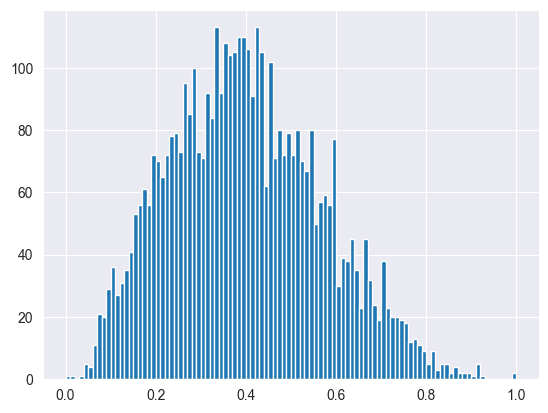

In [2]:
from sklearn.datasets import fetch_openml
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split

df = fetch_openml('mtp', version=1)

plt.hist(df.target, 100)
_ = plt.plot()

-1.651134076973218


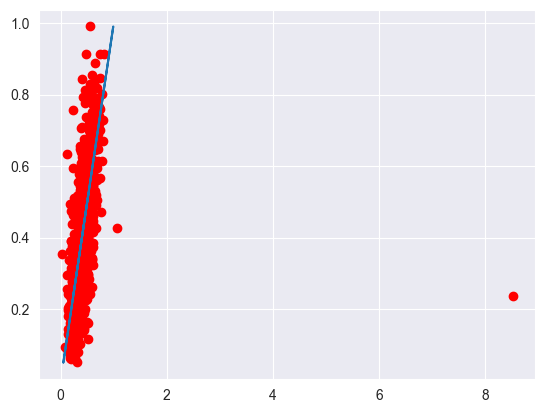

In [3]:
from sklearn.linear_model import LinearRegression, LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(df.data, df.target, test_size=0.25, random_state=42)

baseline = LinearRegression()
baseline.fit(X_train, y_train)
b1_score = baseline.score(X_test, y_test)
print(b1_score)

y_pred = baseline.predict(X_test)

plt.plot(y_test, y_test)
plt.scatter(y_pred, y_test, color='red')
plt.show()

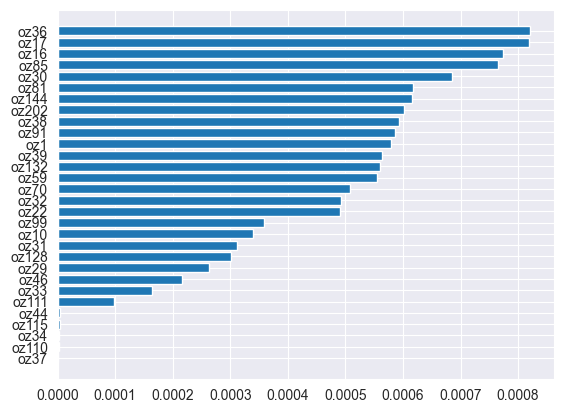

[0.01173296 0.01192054 0.01278174 0.01391015 0.01864071 0.02130099
 0.03365049 0.04101107 0.07338965 0.1530463 ]
Index(['oz117', 'oz197', 'oz112', 'oz198', 'oz137', 'oz18', 'oz35', 'oz48',
       'oz15', 'oz141'],
      dtype='object')


In [4]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=15).fit(X_train, y_train)

sort = rf.feature_importances_.argsort()
plt.barh(df.data.columns[sort][:30], rf.feature_importances_[sort][:30])
plt.show()

print(rf.feature_importances_[sort][-10:])
print(df.data.columns[sort][-10:])

trimmed = df.data[df.data.columns[sort][-20:]]


0.35606963065561803


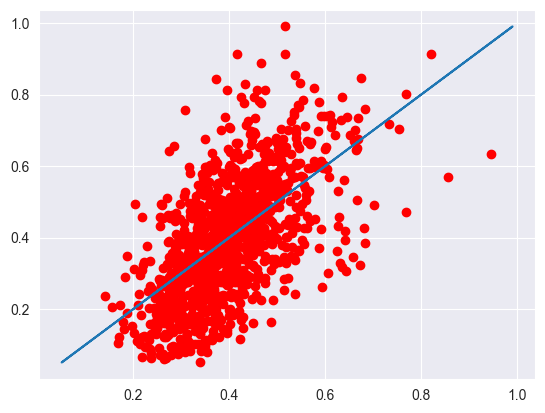

In [5]:
X_train, X_test, y_train, y_test = train_test_split(trimmed, df.target, test_size=0.25, random_state=42)

baseline = LinearRegression()
baseline.fit(X_train, y_train)
b1_score = baseline.score(X_test, y_test)
print(b1_score)

y_pred = baseline.predict(X_test)

plt.plot(y_test, y_test)
plt.scatter(y_pred, y_test, color='red')
plt.show()

0.44588376150850906


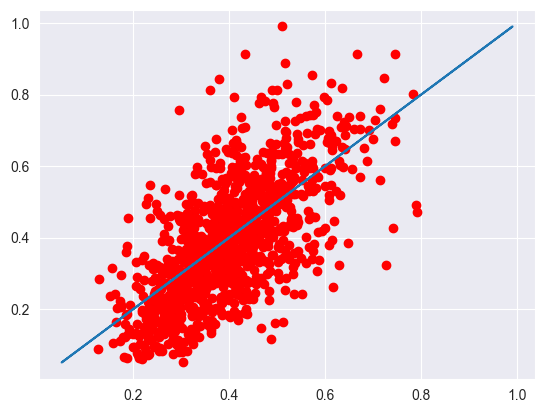

In [51]:
from sklearn.feature_selection import SelectFromModel

sfm = SelectFromModel(RandomForestRegressor(n_estimators=15)).fit(df.data, df.target)
X_trimmed = sfm.transform(df.data)

X_train, X_test, y_train, y_test = train_test_split(X_trimmed, df.target, test_size=0.25, random_state=42)

better = LinearRegression()
better.fit(X_train, y_train)

print(better.score(X_test, y_test))
y_pred = better.predict(X_test)

plt.plot(y_test, y_test)
plt.scatter(y_pred, y_test, color='red')
plt.show()

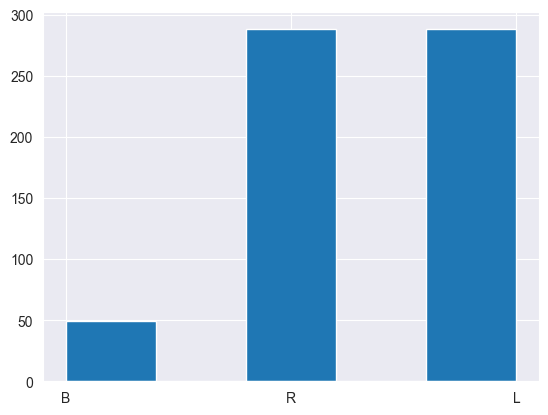

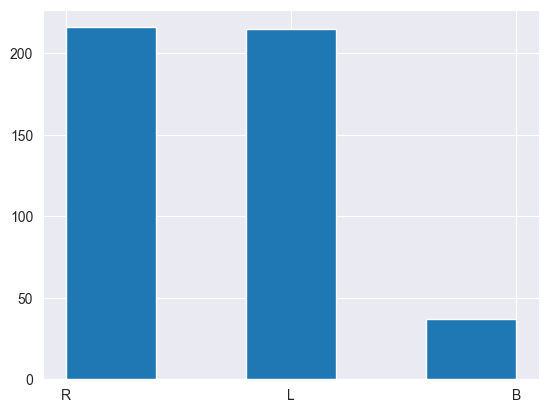

In [32]:
df = fetch_openml('balance-scale', version=1)

plt.hist(df.target, 5)
plt.show()

X_train1, X_test1, y_train1, y_test1 = train_test_split(df.data, df.target, test_size=0.25, random_state=42, stratify=df.target)

plt.hist(y_train1, 5)
plt.show()


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

baseline = LogisticRegression()
baseline.fit(X_train1, y_train1)
b1_score = baseline.score(X_test1, y_test1)
print(b1_score)

print(classification_report(y_test1, baseline.predict(X_test1)))
print(confusion_matrix(y_test1, baseline.predict(X_test1)))


0.8598726114649682
              precision    recall  f1-score   support

           B       0.00      0.00      0.00        12
           L       0.87      0.92      0.89        73
           R       0.86      0.94      0.90        72

    accuracy                           0.86       157
   macro avg       0.58      0.62      0.60       157
weighted avg       0.80      0.86      0.83       157

[[ 0  6  6]
 [ 1 67  5]
 [ 0  4 68]]


In [34]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_train1), y=y_train1)
class_weights = dict(zip(np.unique(y_train1), class_weights))
print(class_weights)

weighted = LogisticRegression(class_weight=class_weights)
weighted.fit(X_train1, y_train1)
print(b1_score)
print(weighted.score(X_test1, y_test1))
print()

print(classification_report(y_test1, weighted.predict(X_test1)))
print(confusion_matrix(y_test1, weighted.predict(X_test1)))

{'B': np.float64(4.216216216216216), 'L': np.float64(0.7255813953488373), 'R': np.float64(0.7222222222222222)}
0.8598726114649682
0.9235668789808917

              precision    recall  f1-score   support

           B       0.61      0.92      0.73        12
           L       0.97      0.92      0.94        73
           R       0.96      0.93      0.94        72

    accuracy                           0.92       157
   macro avg       0.85      0.92      0.87       157
weighted avg       0.94      0.92      0.93       157

[[11  0  1]
 [ 4 67  2]
 [ 3  2 67]]


(647, 5)
     left-weight  left-distance  right-weight  right-distance target
305            3              3             2               1      L
165            2              2             4               1      B
616            5              5             4               2      L
336            3              4             3               2      L
213            2              4             3               4      R


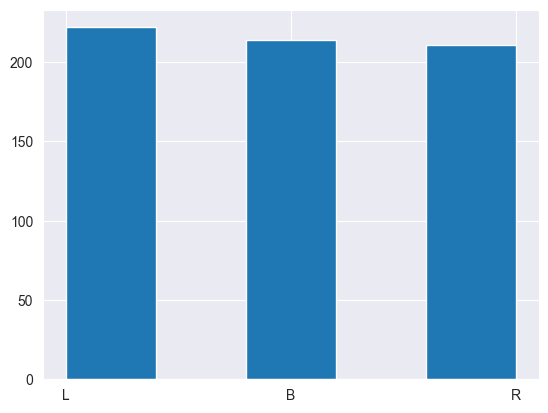

In [43]:
y_train1.value_counts()

X_train['target'] = y_train

oversampled = X_train[X_train.target == 'B'].sample(n=216-37, replace=True, ignore_index=True)

oversampled = pd.concat([X_train, oversampled])
print(oversampled.shape)
print(oversampled.head())

plt.hist(oversampled['target'], 5)
plt.show()

In [45]:
y_train_OS = oversampled.target
X_train_OS = oversampled.drop('target', axis=1)

OSmodel = LogisticRegression()
OSmodel.fit(X_train_OS, y_train_OS)
print(b1_score)
print(OSmodel.score(X_test, y_test))
print(classification_report(y_test, OSmodel.predict(X_test)))

0.8598726114649682
0.89171974522293
              precision    recall  f1-score   support

           B       0.44      0.86      0.59        14
           L       0.97      0.92      0.95        66
           R       1.00      0.87      0.93        77

    accuracy                           0.89       157
   macro avg       0.80      0.88      0.82       157
weighted avg       0.94      0.89      0.91       157



C:\Users\user\AppData\Local\Temp\ipykernel_18668\1394352311.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.data.drop(['instance_id'], inplace=True, axis=1)


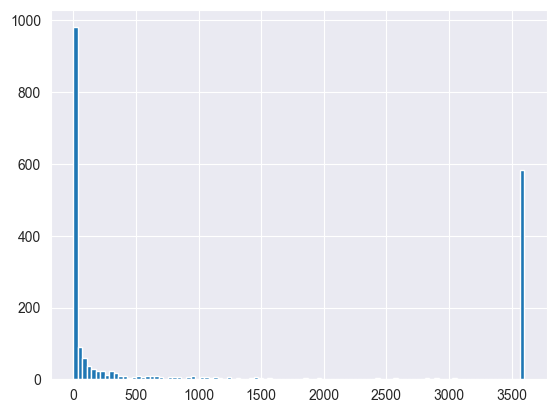

In [46]:
df = fetch_openml("CPMP-2015-regression", version=1)
df.data.drop(['instance_id'], inplace=True, axis=1)
df.data = pd.get_dummies(df.data)

plt.hist(df.target, 100)
plt.show()

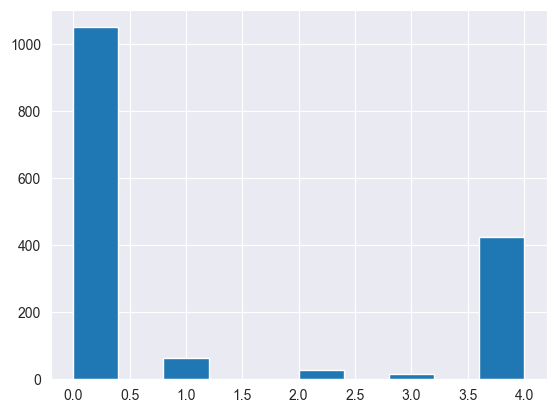

C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


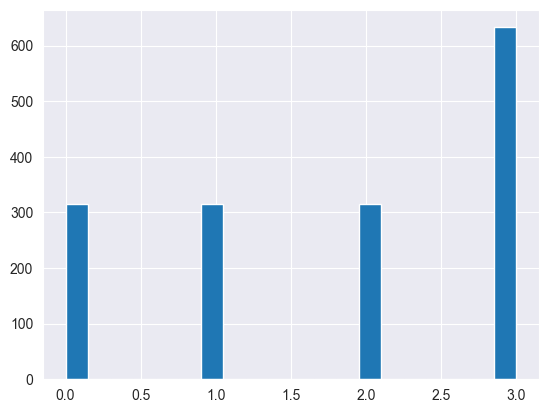

In [49]:
from sklearn.preprocessing import KBinsDiscretizer

X_train, X_test, y_train, y_test = train_test_split(df.data, df.target, test_size=0.25, random_state=42)

y_binned = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="uniform").fit_transform(pd.DataFrame(y_train))

plt.hist(y_binned, 10)
plt.show()

y_binned = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="quantile").fit_transform(pd.DataFrame(y_train))

plt.hist(y_binned, 20)
plt.show()


-1.292963407165558
-1.292963407165558


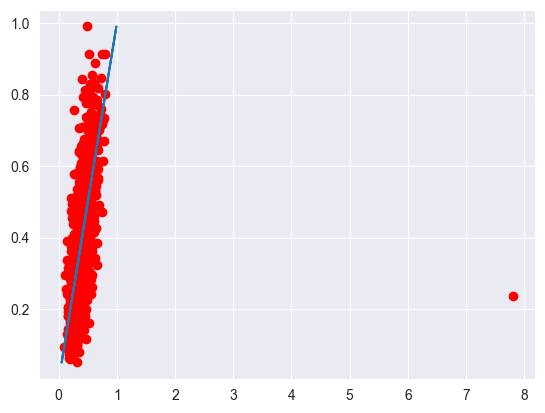

In [54]:
from sklearn.feature_selection import VarianceThreshold

df = fetch_openml('mtp', version=1)

vt = VarianceThreshold(threshold=0.01).fit(df.data, df.target)
X_trimmed = vt.transform(df.data)

X_train, X_test, y_train, y_test = train_test_split(X_trimmed, df.target, test_size=0.25, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

b1_score = model.score(X_test, y_test)
print(b1_score)
print(model.score(X_test, y_test))
y_pred = model.predict(X_test)

plt.plot(y_test, y_test)
plt.scatter(y_pred, y_test, color='red')
plt.show()

0.2544607141087709
0.2544607141087709


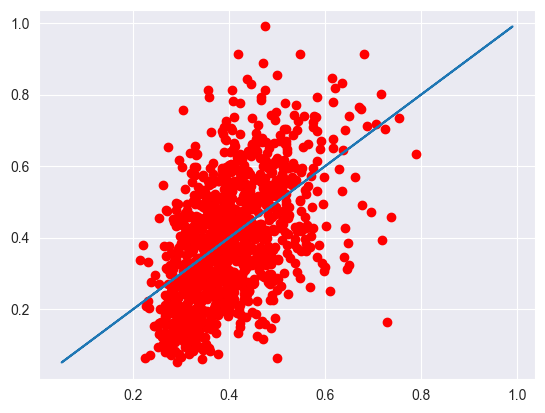

0.22295099767845938
0.22295099767845938


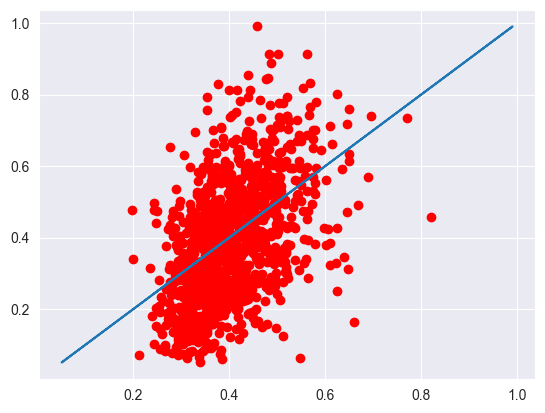

In [58]:
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression

selector = SelectKBest(score_func=f_regression, k=10).fit(df.data, df.target)
X_trimmed = selector.transform(df.data)

X_train, X_test, y_train, y_test = train_test_split(X_trimmed, df.target, test_size=0.25, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

b1_score = model.score(X_test, y_test)
print(b1_score)
print(model.score(X_test, y_test))
y_pred = model.predict(X_test)

plt.plot(y_test, y_test)
plt.scatter(y_pred, y_test, color='red')
plt.show()

selector = SelectKBest(score_func=mutual_info_regression, k=10).fit(df.data, df.target)
X_trimmed = selector.transform(df.data)

X_train, X_test, y_train, y_test = train_test_split(X_trimmed, df.target, test_size=0.25, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

b1_score = model.score(X_test, y_test)
print(b1_score)
print(model.score(X_test, y_test))
y_pred = model.predict(X_test)

plt.plot(y_test, y_test)
plt.scatter(y_pred, y_test, color='red')
plt.show()

-1.651134076973218
-1.651134076973218


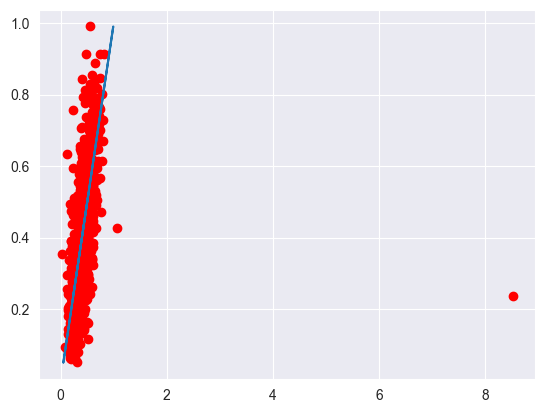

In [65]:
X = pd.DataFrame(df.data, columns=df.feature_names)
y = df.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
corr = X.corrwith(y_train).abs()
selected_features = corr.sort_values(ascending=False).head(10).index

X_trimmed = X[selected_features]

model = LinearRegression()
model.fit(X_train, y_train)

b1_score = model.score(X_test, y_test)
print(b1_score)
print(model.score(X_test, y_test))
y_pred = model.predict(X_test)

plt.plot(y_test, y_test)
plt.scatter(y_pred, y_test, color='red')
plt.show()

In [69]:
from sklearn.feature_selection import RFE

X = pd.DataFrame(df.data, columns=df.feature_names)
y = df.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

rfe = RFE(RandomForestRegressor(random_state=42), n_features_to_select=10)
rfe.fit(X_train, y_train)

X_train_sel = rfe.transform(X_train)
X_test_sel = rfe.transform(X_test)

model = LinearRegression()
model.fit(X_train_sel, y_train)

print(model.score(X_test_sel, y_test))

y_pred = model.predict(X_test_sel)

plt.plot(y_test, y_test)
plt.scatter(y_pred, y_test, color='red')
plt.show()

KeyboardInterrupt: 

In [71]:
from sklearn.feature_selection import SequentialFeatureSelector

X = pd.DataFrame(df.data, columns=df.feature_names)
y = df.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

selector = SequentialFeatureSelector(
    RandomForestRegressor(random_state=42),
    n_features_to_select=10,
    direction='forward'
)

selector.fit(X_train, y_train)

X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)

model = LinearRegression()
model.fit(X_train_sel, y_train)

print("Score:", model.score(X_test_sel, y_test))

y_pred = model.predict(X_test_sel)

plt.plot(y_test, y_test)
plt.scatter(y_pred, y_test, color='red')
plt.show()

KeyboardInterrupt: 

0.17402696264905915


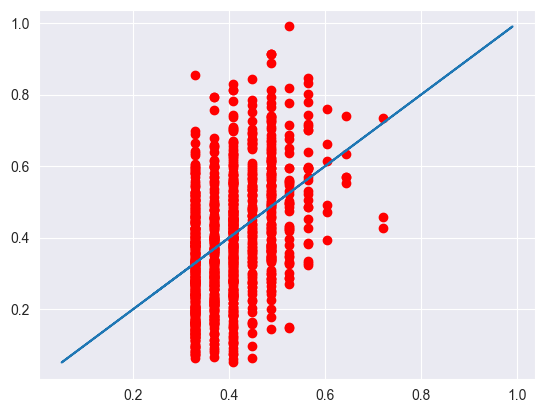

In [80]:
from sklearn.linear_model import Lasso

X = pd.DataFrame(df.data, columns=df.feature_names)
y = df.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = Lasso(alpha=0.01)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

coef = model.coef_

selected_features = X.columns[coef != 0]

X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

final_model = LinearRegression()
final_model.fit(X_train_sel, y_train)

print(final_model.score(X_test_sel, y_test))
y_pred = final_model.predict(X_test_sel)

plt.plot(y_test, y_test)
plt.scatter(y_pred, y_test, color='red')
plt.show()

In [86]:
from imblearn.over_sampling import SMOTE

X = pd.DataFrame(df.data, columns=df.feature_names)
y = df.target

y_binned = pd.qcut(y, q=3, labels=["low", "mid", "high"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y_binned, test_size=0.25, random_state=42
)

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.25, random_state=42
)

final_model = LogisticRegression()
final_model.fit(X_train, y_train)

print(final_model.score(X_test, y_test))
y_pred = final_model.predict(X_test)

0.5988304093567252


C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [91]:
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = pd.DataFrame(df.data, columns=df.feature_names)
y = df.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

reg = LinearRegression()
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)
baseline_score = r2_score(y_test, y_pred)

print(baseline_score)

y_cut = pd.cut(y, bins=10, labels=False)

def run_experiment(y_binned):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_binned, test_size=0.25, random_state=42
    )

    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    return accuracy_score(y_test, y_pred)

results = {}

for bins in [2, 3, 5]:
    y_cut = pd.cut(y, bins=bins, labels=False)
    acc_cut = run_experiment(y_cut)

    y_qcut = pd.qcut(y, q=bins, labels=False, duplicates='drop')
    acc_qcut = run_experiment(y_qcut)

    results[f"cut_{bins}"] = acc_cut
    results[f"qcut_{bins}"] = acc_qcut

print(results)

-1.651134076973218
{'cut_2': 0.8230008984725966, 'qcut_2': 0.7529200359389039, 'cut_3': 0.710691823899371, 'qcut_3': 0.6190476190476191, 'cut_5': 0.5525606469002695, 'qcut_5': 0.44384546271338726}
